# Tâche 2 — Correction du data leakage : PCA

Ce notebook compare quatre approches de réduction de dimensionnalité avec PCA sur le dataset ABIDE :

- **Approche 1** — PCA appliquée avant la CV, GroupKFold (data leakage)
- **Approche 2** — PCA intégrée dans un pipeline CV, GroupKFold (corrigé)
- **Approche 3** — PCA appliquée avant la CV, StratifiedGroupKFold (data leakage)
- **Approche 4** — PCA intégrée dans un pipeline CV, StratifiedGroupKFold (corrigé)

Classifieur : LinearSVC  
CV : GroupKFold(10) ou StratifiedGroupKFold(10) avec groups=sites

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, cross_val_score

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
import prepare_data_v2

In [2]:
data_dir   = os.environ.get('SOURCE_DATA_DIR', '../../data')
output_dir = os.environ.get('OUTPUT_DATA_DIR', '../output')

X, y = prepare_data_v2.prepare_data(data_dir, output_dir)
X = np.array(X)
y = np.array(y)

abide  = datasets.fetch_abide_pcp(data_dir=data_dir, pipeline='cpac', quality_checked=True)
pheno  = pd.DataFrame(abide.phenotypic)
groups = [s.decode() if isinstance(s, bytes) else s for s in pheno.SITE_ID]

print(f'Features shape : {X.shape}')
print(f'{X.shape[0]} sujets · {len(set(groups))} sites')

Chargement du dataset...
[fetch_abide_pcp] Dataset found in ../../data/ABIDE_pcp
[fetch_atlas_basc_multiscale_2015] Dataset found in /home/evavi/nilearn_data/basc_multiscale_2015
Fichier de features trouvé.
[fetch_abide_pcp] Dataset found in ../../data/ABIDE_pcp
Features shape : (871, 2016)
871 sujets · 20 sites


## Approche 1 — PCA avant CV (leakage)

In [3]:
pca = PCA(0.99)
X_pca = pca.fit_transform(X)

print(f'Dimensions après PCA : {X_pca.shape[1]} composantes (variance expliquée >= 99%)')

clf = LinearSVC(max_iter=10000)
gkf = GroupKFold(n_splits=10)

#ici j'ai remplacé la boucle du code original en utilisant cross_val_scores 
scores_leakage = cross_val_score(clf, X_pca, y, groups=groups, cv=gkf, n_jobs=-1) 

print(f'\nApproche 1 — PCA avant CV (leakage)')
print(f'  Accuracy par fold : {np.round(scores_leakage, 3)}')
print(f'  Moyenne           : {scores_leakage.mean():.3f}')
print(f'  Écart-type        : {scores_leakage.std():.3f}')

Dimensions après PCA : 571 composantes (variance expliquée >= 99%)

Approche 1 — PCA avant CV (leakage)
  Accuracy par fold : [0.605 0.686 0.667 0.582 0.72  0.528 0.676 0.696 0.651 0.547]
  Moyenne           : 0.636
  Écart-type        : 0.063


## Approche 2 — PCA dans le pipeline CV (corrigé)

In [5]:
pipeline = Pipeline([
    ('pca', PCA(0.99)),
    ('clf',    LinearSVC(max_iter=10000))
])

gkf = GroupKFold(n_splits=10)

scores_corrected = cross_val_score(pipeline, X, y, groups=groups, cv=gkf, n_jobs=-1)

print(f'Approche 2 — PCA dans le pipeline CV (corrigé)')
print(f'  Accuracy par fold : {np.round(scores_corrected, 3)}')
print(f'  Moyenne           : {scores_corrected.mean():.3f}')
print(f'  Écart-type        : {scores_corrected.std():.3f}')

Approche 2 — PCA dans le pipeline CV (corrigé)
  Accuracy par fold : [0.593 0.721 0.692 0.608 0.68  0.583 0.676 0.696 0.675 0.605]
  Moyenne           : 0.653
  Écart-type        : 0.047


## Approche 3 — PCA avant CV, StratifiedGroupKFold (leakage)

In [6]:
sgkf = StratifiedGroupKFold(n_splits=10)

scores_leakage_sgkf = cross_val_score(clf, X_pca, y, groups=groups, cv=sgkf, n_jobs=-1)

print(f'Approche 3 — PCA avant CV, StratifiedGroupKFold (leakage)')
print(f'  Accuracy par fold : {np.round(scores_leakage_sgkf, 3)}')
print(f'  Moyenne           : {scores_leakage_sgkf.mean():.3f}')
print(f'  Écart-type        : {scores_leakage_sgkf.std():.3f}')

Approche 3 — PCA avant CV, StratifiedGroupKFold (leakage)
  Accuracy par fold : [0.672 0.686 0.698 0.562 0.577 0.636 0.522 0.587 0.605 0.735]
  Moyenne           : 0.628
  Écart-type        : 0.065


## Approche 4 — PCA dans le pipeline CV, StratifiedGroupKFold (corrigé)

In [7]:
pipeline_sgkf = Pipeline([
    ('pca', PCA(0.99)),
    ('clf', LinearSVC(max_iter=10000))
])

scores_corrected_sgkf = cross_val_score(pipeline_sgkf, X, y, groups=groups, cv=sgkf, n_jobs=-1)

print(f'Approche 4 — PCA dans le pipeline CV, StratifiedGroupKFold (corrigé)')
print(f'  Accuracy par fold : {np.round(scores_corrected_sgkf, 3)}')
print(f'  Moyenne           : {scores_corrected_sgkf.mean():.3f}')
print(f'  Écart-type        : {scores_corrected_sgkf.std():.3f}')

Approche 4 — PCA dans le pipeline CV, StratifiedGroupKFold (corrigé)
  Accuracy par fold : [0.701 0.721 0.719 0.594 0.563 0.659 0.594 0.613 0.593 0.711]
  Moyenne           : 0.647
  Écart-type        : 0.059


## Visualisation

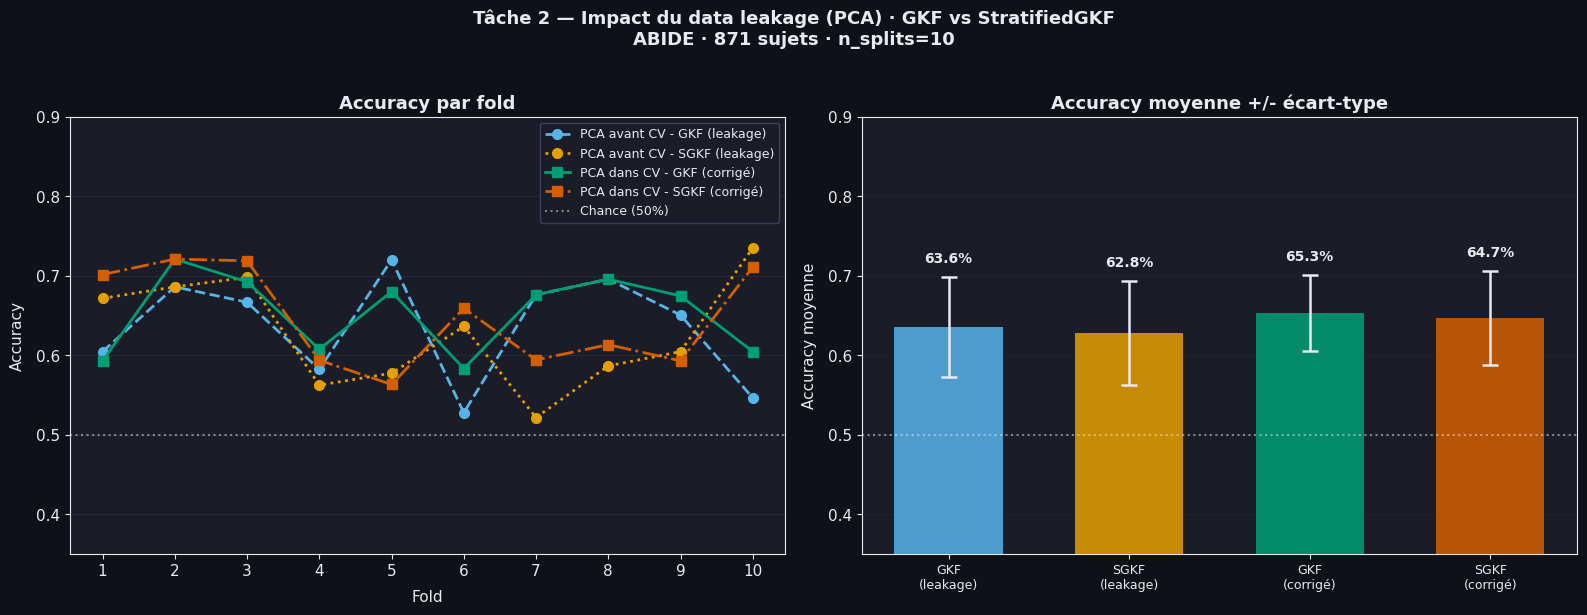

In [8]:
BG     = '#0e1117'
PANEL  = '#1a1d27'
TEXT   = '#e8eaf0'
COLORS = ['#56B4E9', '#E69F00', '#009E73', '#D55E00']
LABELS = [
    'PCA avant CV - GKF (leakage)',
    'PCA avant CV - SGKF (leakage)',
    'PCA dans CV - GKF (corrigé)',
    'PCA dans CV - SGKF (corrigé)',
]

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.edgecolor':   TEXT, 'axes.labelcolor': TEXT,
    'xtick.color':      TEXT, 'ytick.color':     TEXT,
    'text.color':       TEXT, 'legend.facecolor': PANEL,
    'legend.edgecolor': '#444466', 'font.size': 11,
    'axes.titlesize':   13, 'axes.titleweight': 'bold',
    'grid.color':       '#2a2d3a', 'grid.linewidth': 0.6,
})

all_scores = [scores_leakage, scores_leakage_sgkf, scores_corrected, scores_corrected_sgkf]
n_folds    = len(scores_leakage)
folds      = np.arange(n_folds)
markers    = ['o', 'o', 's', 's']
lines      = ['--', ':', '-', '-.']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)

# Panel gauche : accuracy par fold
ax = axes[0]
for scores, label, color, marker, line in zip(all_scores, LABELS, COLORS, markers, lines):
    ax.plot(folds, scores, marker=marker, linestyle=line, label=label,
            color=color, linewidth=2, markersize=7)
ax.axhline(0.5, color=TEXT, linestyle=':', linewidth=1.5, alpha=0.5, label='Chance (50%)')
ax.set_xlabel('Fold', labelpad=8)
ax.set_ylabel('Accuracy', labelpad=8)
ax.set_title('Accuracy par fold')
ax.set_xticks(folds)
ax.set_xticklabels([str(i + 1) for i in folds])
ax.set_ylim(0.35, 0.90)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(framealpha=0.85, fontsize=9)

# Panel droit : accuracy moyenne +/- écart-type
ax    = axes[1]
means = [s.mean() for s in all_scores]
stds  = [s.std()  for s in all_scores]
x_pos = np.arange(4)
bars  = ax.bar(x_pos, means, yerr=stds, capsize=6,
               color=COLORS, alpha=0.85, width=0.6,
               error_kw={'ecolor': TEXT, 'elinewidth': 1.8, 'capthick': 1.8})
ax.axhline(0.5, color=TEXT, linestyle=':', linewidth=1.5, alpha=0.5)
ax.set_ylabel('Accuracy moyenne', labelpad=8)
ax.set_title('Accuracy moyenne +/- écart-type')
ax.set_xticks(x_pos)
ax.set_xticklabels([
    'GKF\n(leakage)', 'SGKF\n(leakage)',
    'GKF\n(corrigé)', 'SGKF\n(corrigé)'
], fontsize=9)
ax.set_ylim(0.35, 0.90)
ax.yaxis.grid(True, alpha=0.5)
ax.set_axisbelow(True)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + std + 0.015,
            f'{mean:.1%}', ha='center', va='bottom',
            fontweight='bold', color=TEXT, fontsize=10)

fig.suptitle(
    f'Tâche 2 — Impact du data leakage (PCA) · GKF vs StratifiedGKF\n'
    f'ABIDE · {X.shape[0]} sujets · n_splits=10',
    fontsize=13, fontweight='bold', color=TEXT, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Tache_2_pca_leakage.png'), bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()

### Interprétation

La différence entre GroupKFold et StratifiedGroupKFold est de moins de 1% pour l'approche PCA corrigée. Bien que StratifiedGroupKFold soit théoriquement plus rigoureux (il garantit que le ratio ASD/contrôles est maintenu dans chaque fold) son apport est négligeable ici.

**Pourquoi ?** Le dataset ABIDE est relativement équilibré (403 ASD / 468 contrôles, soit ~46/54%). Avec des proportions aussi proches, GroupKFold seul crée des folds suffisamment équilibrés sans stratification explicite. StratifiedGroupKFold apporterait un gain plus notable sur un dataset fortement déséquilibré (ex. 80/20). 

**Conclusion** : pour ABIDE, GroupKFold(10) est suffisant. StratifiedGroupKFold reste une bonne pratique à adopter par défaut, mais ne change pas les résultats ici. C'est ce qui guide la décision de continuer la tache 3 avec le GroupKFold 